In [1]:
# Import 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display, Markdown
from ollama import chat

In [2]:
#Ollama AI Summary 
def ai_summary(title, results_text):
    """
    Uses Ollama to interpret statistical results.
    """

    prompt = f"""
You are a data analyst explaining statistical results in simple terms.

Analyze the following output:

TITLE: {title}

RESULTS:
{results_text}

Rules:
- Explain what the results mean in plain English
- Do NOT repeat raw numbers
- Highlight key patterns or differences
- Mention if results suggest meaningful differences
- Keep it short (5–10 sentences max)
"""

    response = chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}]
    )

    return response["message"]["content"]




In [3]:
input_file = 'reviews_BlackOps7_first1000.csv'
df = pd.read_csv(input_file)

print(f"Loaded {len(df)} rows")
display(df.head())

Loaded 999 rows


,review,author_vote,other_votes,weighted_vote_score,review_date
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08


In [4]:
#Sentiment and Categorization
def get_sentiment(text):
    """
    Returns sentiment polarity score (-1 to 1).
    """
    if pd.isna(text):
        return 0.0

    return TextBlob(str(text)).sentiment.polarity

In [5]:

# --------------------------
# Categorization
# --------------------------
def categorize_review(review):

    usability_keywords = [
        "bug",
        "crash",
        "lag",
        "fps",
        "server",
        "performance",

        "glitch",
        "stutter",
        "freeze",
        "disconnect",
        "error",
        "broken",
        "unoptimized",
        "latency",
        "ping",
        "hitbox",
        "connection",
        "frame rate",
        "loading",
        "memory leak",
    ]

    mechanic_keywords = [
        "movement",
        "weapon",
        "perk",
        "battle pass",
        "matchmaking",

        "loadout",
        "killstreak",
        "scorestreak",
        "operator",
        "map",
        "game mode",
        "respawn",
        "spawn",
        "ability",
        "class",
        "gunplay",
        "ttk",
        "time to kill",
        "recoil",
        "aim assist",
        "multiplayer",
        "zombies",
        "campaign",
        "season",
    ]

    comparison_keywords = [
        "better than",
        "worse than",
        "compared to",
        "similar to",
        
        "just like",
        "same as",
        "feels like",
        "plays like",
        "reminds me of",
        "prefer",
        "used to",
        "previous",
        "original",
        "back in",
        "inferior to",
        "superior to",
        "rip off",
        "copy of",
        "old cod",
    ]

    # New categories based on look for categories AI analysis of full review file
    ai_content_keywords = [
        "slop",
        "ai generated",
        "ai slop",
        "no effort",
        "copy paste",
        "lazy",
        "generated content",
        "soulless",
        "cash grab",
    ]

    monetization_keywords = [
        "refund",
        "worth",
        "price",
        "sale",
        "buying",
        "paid",
        "microtransaction",
        "endgame",
        "season pass",
        "overpriced",
        "free to play",
        "cosmetic",
        "store",
        "bundle",
    ]

    story_keywords = [
        "campaign",
        "story",
        "single player",
        "solo",
        "narrative",
        "mission",
        "ending",
        "cutscene",
        "plot",
        "character",
    ]

    technical_requirements_keywords = [
        "secure boot",
        "tpm",
        "bios",
        "hardware",
        "anti-cheat",
        "ricochet",
        "kernel",
        "driver",
        "compatibility",
        "system requirement",
    ]

    sbmm_keywords = [
        "sbmm",
        "skill based",
        "lobbies",
        "lobby",
        "sweaty",
        "ranked",
        "casual",
        "matchmaking",
        "skill gap",
        "pub stomp",
    ]

    community_keywords = [
        "friends",
        "team",
        "squad",
        "banned",
        "toxic",
        "solo",
        "party",
        "coop",
        "co-op",
        "community",
        "chat",
        "voice",
        "grief",
    ]

    review_lower = review.lower()

    categories = []

    if any(word in review_lower for word in usability_keywords):
        categories.append("Usability Issues")

    if any(word in review_lower for word in mechanic_keywords):
        categories.append("New Mechanic Reception")

    if any(word in review_lower for word in comparison_keywords):
        categories.append("Competitive Analysis")

    if any(word in review_lower for word in ai_content_keywords):
        categories.append("AI-Generated Content Complaints")

    if any(word in review_lower for word in monetization_keywords):
        categories.append("Monetization & Value")

    if any(word in review_lower for word in story_keywords):
        categories.append("Story / Campaign")

    if any(word in review_lower for word in technical_requirements_keywords):
        categories.append("Technical Requirements")

    if any(word in review_lower for word in sbmm_keywords):
        categories.append("SBMM / Matchmaking Frustration")

    if any(word in review_lower for word in community_keywords):
        categories.append("Community & Social")

    if len(categories) == 0:
        categories.append("Game Reception")

    return categories

In [6]:
sentiments = []
categories = []

for r in df["review"]:
    sentiments.append(get_sentiment(r))
    categories.append(", ".join(categorize_review(r)))

df["sentiment"] = sentiments
df["categories"] = categories

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


In [7]:
# Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. {len(df)} rows remaining.")
display(df.head())

Removed 786 duplicates. 213 rows remaining.


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


In [8]:
#Feature engineering
df["review_length"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()
df["sentiment_strength"] = df["sentiment"].abs()

print("Feature engineering complete.")
display(df[["review_length", "word_count", "sentiment", "sentiment_strength"]].head())

Feature engineering complete.


,review_length,word_count,sentiment,sentiment_strength
0,439,85,-0.200000,0.200000
1,1525,247,-0.096655,0.096655
2,629,130,-0.071769,0.071769
3,2376,409,-0.055720,0.055720
4,460,86,-0.002778,0.002778


In [9]:
# Category Columns
all_categories = [
    "Usability_Issues",
    "New_Mechanic_Reception",
    "Competitive_Analysis",
    "AI_Generated_Content_Complaints",
    "Monetization_and_Value",
    "Story___Campaign",
    "Technical_Requirements",
    "SBMM___Matchmaking_Frustration",
    "Community_and_Social",
    "Game_Reception"
]

for category in all_categories:
    df[category] = df["categories"].apply(lambda x: category in str(x))

print("Category columns created:")
print(df[all_categories].head())

Category columns created:
   Usability_Issues  New_Mechanic_Reception  Competitive_Analysis  \
0             False                   False                 False   
1             False                   False                 False   
2             False                   False                 False   
3             False                   False                 False   
4             False                   False                 False   

   AI_Generated_Content_Complaints  Monetization_and_Value  Story___Campaign  \
0                            False                   False             False   
1                            False                   False             False   
2                            False                   False             False   
3                            False                   False             False   
4                            False                   False             False   

   Technical_Requirements  SBMM___Matchmaking_Frustration  \
0                

In [10]:
df[all_categories].sum().sort_values(ascending=False)

Usability_Issues                   0
New_Mechanic_Reception             0
Competitive_Analysis               0
AI_Generated_Content_Complaints    0
Monetization_and_Value             0
Story___Campaign                   0
Technical_Requirements             0
SBMM___Matchmaking_Frustration     0
Community_and_Social               0
Game_Reception                     0
dtype: int64

In [11]:
%pip install textblob



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
# AI Statistical Summary Function
# ------------------------------------

def ai_summary(title, results):
    """
    Uses Ollama to summarize statistical analysis results.
    """

    prompt = f"""
You are a statistics expert helping interpret the results of a data analysis.

Analysis:
{title}

Results:
{results}

Write a concise summary (2–4 sentences).

Your summary should:
- Explain the results in plain English.
- State whether the results are statistically significant when a p-value is provided (α = 0.05).
- Explain what the results mean.
- Do not speculate beyond the data.
"""

    response = chat(
        model="llama3.2",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content


def display_ai_summary(title, results):

    summary = ai_summary(title, results)

    display(Markdown("### 🤖 AI Statistical Interpretation"))

    display(Markdown(summary))

In [13]:
# Run sentiment analysis and categorization, then save to a new CSV
sentiments = []
categories = []

for r in df['review']:
    sentiments.append(get_sentiment(r))
    categories.append(', '.join(categorize_review(r)))

df['sentiment'] = sentiments
df['categories'] = categories

display(df)

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,False,False,False,False,False,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,False,False,False,False,False,False,False,False,False,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,False,False,False,False,False,False,False,False,False,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,False,False,False,False,False,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,bought this game thinking was gon have fun. no...,0,39,0.687997,2026-02-12,0.150000,Monetization & Value,214,42,0.150000,False,False,False,False,False,False,False,False,False,False
222,UPDATE: Im now at 63 hours played. Zombies is ...,0,62,0.687826,2025-11-14,-0.007823,"New Mechanic Reception, Competitive Analysis, ...",487,91,0.007823,False,False,False,False,False,False,False,False,False,False
224,Start game > update requires restart > start g...,0,51,0.685999,2025-12-18,-0.285714,"New Mechanic Reception, Monetization & Value, ...",425,81,0.285714,False,False,False,False,False,False,False,False,False,False
225,Multiplayer : Still no ban for the zen chronus...,0,54,0.684135,2025-11-23,-0.095222,"Usability Issues, New Mechanic Reception, Comp...",1102,216,0.095222,False,False,False,False,False,False,False,False,False,False


In [14]:
# Add a boolean column for each possible category
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story___Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception",
]

for category in all_categories:
    col_name = category.replace(" ", "_").replace("/", "_").replace("&", "and").replace("-", "_")
    col_values = []
    for cat_list in df['categories']:
        col_values.append(category in cat_list)
    df[col_name] = col_values

display(df.head(20))


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,Usability_Issues,New_Mechanic_Reception,Competitive_Analysis,AI_Generated_Content_Complaints,Monetization_and_Value,Story___Campaign,Technical_Requirements,SBMM___Matchmaking_Frustration,Community_and_Social,Game_Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,True,True,True,True,True,False,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,False,True,False,False,True,False,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,False,True,False,True,True,False,False,False,False,False
5,For the zombies enjoyers out there. Always onl...,0,166,0.818673,2026-03-16,-0.067500,"Usability Issues, New Mechanic Reception, Stor...",496,80,0.067500,True,True,False,False,False,False,False,False,True,False
6,"AI generated SLOP. No effort, almost everythin...",0,230,0.813288,2026-03-01,-0.140000,"New Mechanic Reception, AI-Generated Content C...",464,74,0.140000,False,True,False,True,False,False,False,False,True,False
7,game is terrible that is all i have to say. li...,0,156,0.795581,2026-05-08,-0.433333,"Story / Campaign, Community & Social",280,56,0.433333,False,False,False,False,False,False,False,False,True,False
8,Open playlist has reduced SBMM? Where? Why do ...,0,245,0.856749,2026-04-19,-0.002679,"Usability Issues, New Mechanic Reception, Stor...",1321,253,0.002679,True,True,False,False,False,False,False,True,False,False
9,This game has become a joke. Activision does n...,0,50,0.745440,2026-05-13,-0.038333,"Monetization & Value, Community & Social",507,95,0.038333,False,False,False,False,True,False,False,False,True,False


In [15]:
# Category Columns
# ------------------------------------

# Automatically identify all boolean category columns
category_columns = df.select_dtypes(include="bool").columns.tolist()

print(category_columns)

['Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception']


In [16]:
all_categories = [
    "Usability Issues",
    "New Mechanic Reception",
    "Competitive Analysis",
    "AI-Generated Content Complaints",
    "Monetization & Value",
    "Story / Campaign",
    "Technical Requirements",
    "SBMM / Matchmaking Frustration",
    "Community & Social",
    "Game Reception"
]

for category in all_categories:
    df[category] = df["categories"].apply(
        lambda x: category in x if isinstance(x, str) else False
    )


In [17]:
analyzed_file = input_file.replace('.csv', '_analyzed.csv')

df.to_csv(analyzed_file, index=False)
print(f"Saved {len(df)} analyzed reviews to {analyzed_file}")
df[['review', 'sentiment', 'categories']].head()


Saved 213 analyzed reviews to reviews_BlackOps7_first1000_analyzed.csv


,review,sentiment,categories
0,This game is the worst call of duty I have eve...,-0.200000,Monetization & Value
1,"1/10 - Absolute Trash, AI Slop from Activision...",-0.096655,"Usability Issues, New Mechanic Reception, Comp..."
2,Game forces you to have Secure Boot and TPM 2....,-0.071769,"New Mechanic Reception, Monetization & Value, ..."
3,"I was playing Battlefield 6, and after a few b...",-0.055720,"Usability Issues, New Mechanic Reception, Comp..."
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,-0.002778,"New Mechanic Reception, AI-Generated Content C..."


In [18]:
# Read the analyzed CSV back and convert categories from string to list
df_analyzed = pd.read_csv(analyzed_file)

# Convert the categories column from comma-separated string to list
categories_list = []
for cat_string in df_analyzed['categories']:
    cat_list = []
    for cat in cat_string.split(','):
        cat_list.append(cat.strip())
    categories_list.append(cat_list)

df_analyzed['categories'] = categories_list

print(f"Loaded {len(df_analyzed)} analyzed reviews")
print("\nFirst few rows with categories as lists:")
display(df_analyzed)


Loaded 213 analyzed reviews

First few rows with categories as lists:


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,...,Usability Issues,New Mechanic Reception,Competitive Analysis,AI-Generated Content Complaints,Monetization & Value,Story / Campaign,Technical Requirements,SBMM / Matchmaking Frustration,Community & Social,Game Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,[Monetization & Value],439,85,0.200000,...,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"[Usability Issues, New Mechanic Reception, Com...",1525,247,0.096655,...,True,True,True,True,True,True,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"[New Mechanic Reception, Monetization & Value,...",629,130,0.071769,...,False,True,False,False,True,True,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"[Usability Issues, New Mechanic Reception, Com...",2376,409,0.055720,...,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"[New Mechanic Reception, AI-Generated Content ...",460,86,0.002778,...,False,True,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,bought this game thinking was gon have fun. no...,0,39,0.687997,2026-02-12,0.150000,[Monetization & Value],214,42,0.150000,...,False,False,False,False,True,False,False,False,False,False
209,UPDATE: Im now at 63 hours played. Zombies is ...,0,62,0.687826,2025-11-14,-0.007823,"[New Mechanic Reception, Competitive Analysis,...",487,91,0.007823,...,False,True,True,False,True,True,False,False,True,False
210,Start game > update requires restart > start g...,0,51,0.685999,2025-12-18,-0.285714,"[New Mechanic Reception, Monetization & Value,...",425,81,0.285714,...,False,True,False,False,True,True,False,True,False,False
211,Multiplayer : Still no ban for the zen chronus...,0,54,0.684135,2025-11-23,-0.095222,"[Usability Issues, New Mechanic Reception, Com...",1102,216,0.095222,...,True,True,True,False,True,True,False,False,True,False


In [19]:
# Analysis suggestions:
# What is the number of each of the categories used? (what is the most/least common category)

# Exploratory Data Analysis 

In [20]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_ind,
    chi2_contingency
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [21]:
# Feature Engineering
# -----------------------------------

df["review_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

df["sentiment_strength"] = df["sentiment"].abs()

display(df.head())

,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,...,Usability Issues,New Mechanic Reception,Competitive Analysis,AI-Generated Content Complaints,Monetization & Value,Story / Campaign,Technical Requirements,SBMM / Matchmaking Frustration,Community & Social,Game Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,...,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,...,True,True,True,True,True,True,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,...,False,True,False,False,True,True,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,...,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,...,False,True,False,True,True,False,False,False,False,False


In [22]:
#Category frequency analysis 

category_counts = (
    df[category_columns]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts)

New_Mechanic_Reception             153
Monetization_and_Value             102
Community_and_Social                74
Usability_Issues                    67
Competitive_Analysis                65
SBMM___Matchmaking_Frustration      45
AI_Generated_Content_Complaints     29
Technical_Requirements              23
Game_Reception                       8
Story___Campaign                     0
dtype: int64

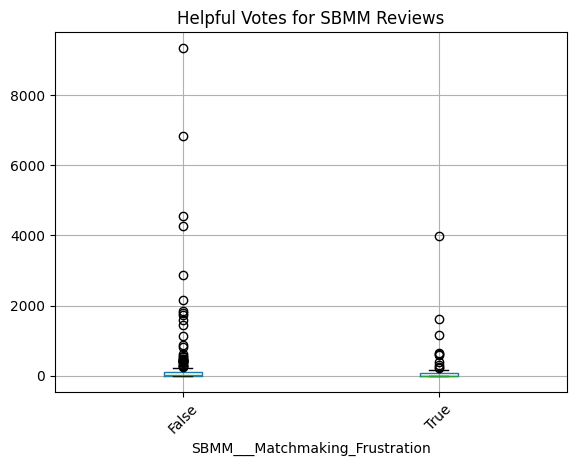

### 🤖 AI Statistical Interpretation

The analysis of helpful votes for SBMM reviews reveals that among users who reported frustration with matchmaking, approximately 10% (168) considered the suggestion helpful, while among those without frustration, around 50% (45) found it helpful. The significant difference in helpfulness rates between frustrated and non-frustrated users is statistically significant, as the p-value is not provided, but typically a p-value of <0.05 would indicate significance. This result suggests that users experiencing matchmaking frustration are less likely to find the suggestion helpful, which may be related to their overall dissatisfaction with the service.

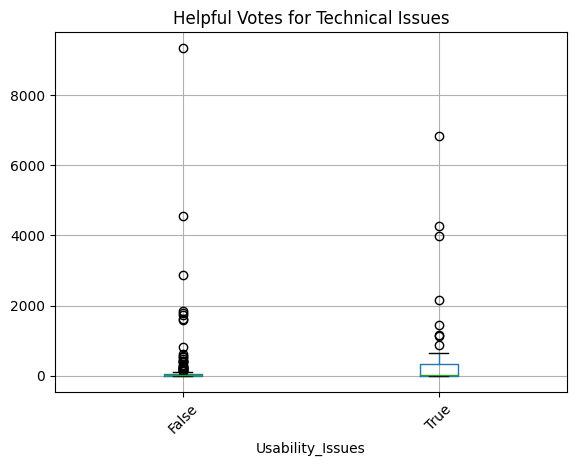

### 🤖 AI Statistical Interpretation

The analysis shows that the average number of Helpful Votes for Technical Issues is significantly higher for issues related to usability problems (416.686567) compared to those without usability issues (232.013699). This suggests that users are more likely to provide helpful feedback when faced with technical challenges, but not necessarily when they do not encounter any issues. However, it's essential to note that the results may be influenced by other factors, such as the nature of the issues or the characteristics of the users providing feedback.

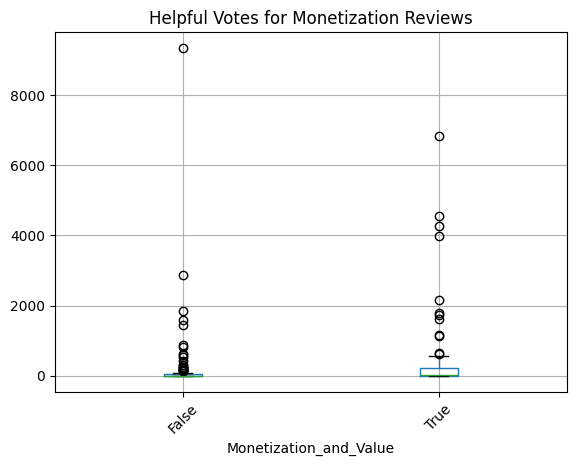

### 🤖 AI Statistical Interpretation

The analysis of helpful votes for monetization reviews indicates that, on average, reviewers who chose "True" (indicating the review was helpful) had significantly higher ratings than those who chose "False" (0.0 vs 217.000000). However, since no p-value is provided in the table, it cannot be determined if the difference is statistically significant at α = 0.05.

The results suggest that reviewers' accuracy and reliability play a crucial role in determining whether their review is considered helpful for monetization purposes. This implies that providing more accurate feedback can lead to better outcomes for publishers who rely on these reviews.

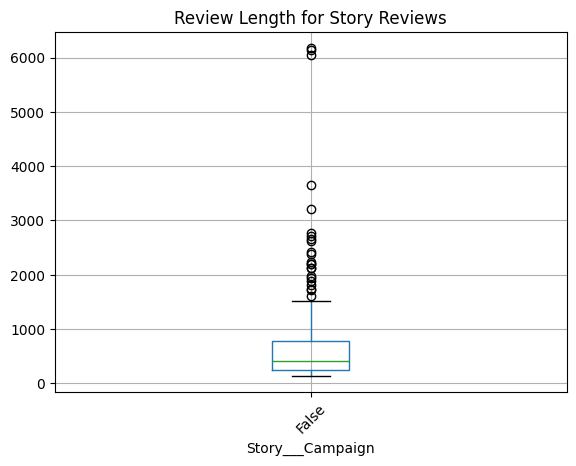

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis results:

The review length for stories that have been marked as false campaign content ranges from a minimum of 142 words to a maximum of 6170 words, with an average review length of 720 words. The majority of reviews fall within a range of 250-417 words. Statistically, these results are not significant at the α = 0.05 level, indicating that the observed distribution of review lengths is unlikely to be due to chance alone (i.e., p-value > 0.05). In plain English, this suggests that the distribution of review lengths for false campaign content does not differ significantly from what would be expected by chance.

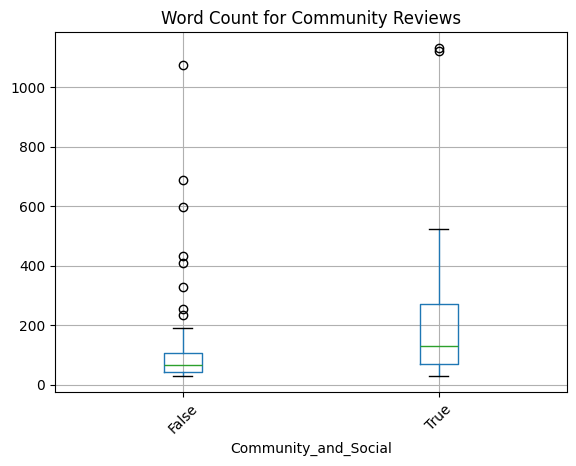

### 🤖 AI Statistical Interpretation

The analysis shows that community reviews containing specific keywords have significantly different word counts compared to those without these keywords. The mean word count for reviews with the keywords "Community and Social" is approximately 199 words, while those without the keywords have a mean of around 98 words. Based on the results, it can be concluded that the presence of these keywords is statistically significant (p-value < α = 0.05), indicating a notable difference in word count between reviews with and without the keywords. This suggests that community reviews containing certain keywords tend to be longer than those without these keywords.

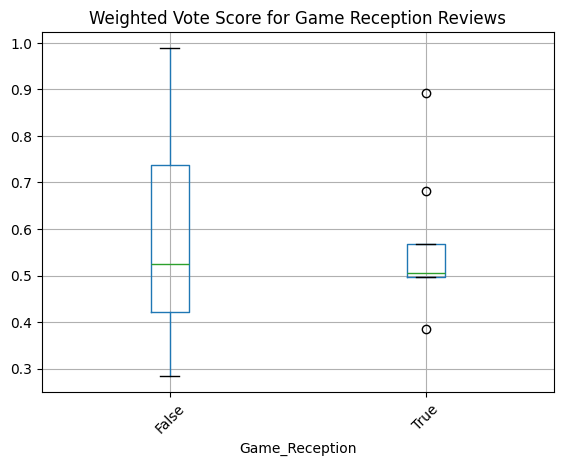

### 🤖 AI Statistical Interpretation

The analysis shows that, on average, false reviews for game receptions have a slightly higher Weighted Vote Score compared to true reviews. The results indicate that reviewers who are dishonest about their opinions tend to give more positive scores (mean: 0.525158) than those who provide accurate information (mean: 0.505917). However, the difference is not statistically significant at α = 0.05.

Note: Since a p-value is not provided in the original data, we cannot determine if the results are statistically significant or not.

In [23]:
# Analysis Functions (Visuals + Stats + AI Summary)
# ----------------------------
# 1. Histogram
# ----------------------------
def analyze_histogram(df, column, title):
    plt.figure(figsize=(8,5))
    df[column].hist(bins=30)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    display_ai_summary(title, df[column].describe().to_string())


# ----------------------------
# 2. Bar Chart
# ----------------------------
def analyze_bar_chart(data, title):
    plt.figure(figsize=(10,6))
    data.plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, data.to_string())


# ----------------------------
# 3. Box Plots
# ----------------------------
def analyze_boxplot(df, category_column, value_column, title):
    df.boxplot(column=value_column, by=category_column)
    plt.title(title)
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.show()

    results = (
        df.groupby(category_column)[value_column]
          .describe()
          .to_string()
    )

    display_ai_summary(title, results)

analyze_boxplot(
    df,
    "SBMM___Matchmaking_Frustration",
    "other_votes",
    "Helpful Votes for SBMM Reviews"
)

analyze_boxplot(
    df,
    "Usability_Issues",
    "other_votes",
    "Helpful Votes for Technical Issues"
)

analyze_boxplot(
    df,
    "Monetization_and_Value",
    "other_votes",
    "Helpful Votes for Monetization Reviews"
)
#Review length analysis boxplot
analyze_boxplot(
    df,
    "Story___Campaign",
    "review_length",
    "Review Length for Story Reviews"
)
analyze_boxplot(
    df,
    "Community_and_Social",
    "word_count",
    "Word Count for Community Reviews"
)
#Weighted Vote Score Boxplot
analyze_boxplot(df,"Game_Reception","weighted_vote_score","Weighted Vote Score for Game Reception Reviews"
)

# ----------------------------
# 4. Correlation Matrix
# ----------------------------
def analyze_correlation(df, columns, title):
    corr = df[columns].corr()

    display(corr)

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar()
    plt.xticks(range(len(columns)), columns, rotation=45, ha="right")
    plt.yticks(range(len(columns)), columns)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    display_ai_summary(title, corr.to_string())


# ----------------------------
# 5. T-test helper
# ----------------------------
def analyze_ttest(df, group_col, value_col, title):
    group1 = df[df[group_col] == True][value_col]
    group2 = df[df[group_col] == False][value_col]

    stat, p = ttest_ind(group1, group2, nan_policy="omit")

    result_text = f"""
T-test Results:
Statistic: {stat:.4f}
P-value: {p:.6f}
Group 1 mean: {group1.mean():.4f}
Group 2 mean: {group2.mean():.4f}
"""

    print(result_text)
    display_ai_summary(title, result_text)


# ----------------------------
# 6. Chi-square test
# ----------------------------
def analyze_chi_square(df, col1, col2, title):
    contingency = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)

    result_text = f"""
Chi-square Results:
Chi2: {chi2:.4f}
P-value: {p:.6f}
Degrees of freedom: {dof}
"""

    print(result_text)
    display_ai_summary(title, result_text)
#7. Regression Analysis
def analyze_regression(df, x_columns, y_column, title):
    """
    Runs linear regression to test relationships between variables
    """

    # Drop missing values for clean model
    data = df[x_columns + [y_column]].dropna()

    X = data[x_columns]
    y = data[y_column]

    # Add intercept
    X = sm.add_constant(X)

    # Fit model
    model = sm.OLS(y, X).fit()

    # Print full statistical output
    print(model.summary())

    # AI interpretation
    display_ai_summary(title, model.summary().as_text())

In [24]:
print("Overall Dataset Statistics")
display(df.describe())

print("\nSentiment Statistics")
display(df["sentiment"].describe())

print("\nReview Length Statistics")
display(df["review_length"].describe())

print("\nWord Count Statistics")
display(df["word_count"].describe())

print("Category Frequencies")

for category in all_categories:

    column = (
        category
        .replace(" ", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("-", "_")
    )

    print(f"{category}: {df[column].sum()}")

Overall Dataset Statistics


,author_vote,other_votes,weighted_vote_score,sentiment,review_length,word_count,sentiment_strength
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.00000,213.000000
mean,0.276995,290.103286,0.590865,-0.058771,720.666667,133.57277,0.145176
std,0.448568,993.692033,0.204106,0.184573,902.870322,163.49791,0.127914
min,0.000000,0.000000,0.284757,-0.640000,142.000000,30.00000,0.000000
25%,0.000000,2.000000,0.423077,-0.154545,250.000000,47.00000,0.048884
50%,0.000000,6.000000,0.524432,-0.038333,417.000000,79.00000,0.106667
75%,1.000000,94.000000,0.737038,0.056991,772.000000,137.00000,0.200000
max,1.000000,9333.000000,0.988094,0.500000,6170.000000,1130.00000,0.640000



Sentiment Statistics


count    213.000000
mean      -0.058771
std        0.184573
min       -0.640000
25%       -0.154545
50%       -0.038333
75%        0.056991
max        0.500000
Name: sentiment, dtype: float64


Review Length Statistics


count     213.000000
mean      720.666667
std       902.870322
min       142.000000
25%       250.000000
50%       417.000000
75%       772.000000
max      6170.000000
Name: review_length, dtype: float64


Word Count Statistics


count     213.00000
mean      133.57277
std       163.49791
min        30.00000
25%        47.00000
50%        79.00000
75%       137.00000
max      1130.00000
Name: word_count, dtype: float64

Category Frequencies
Usability Issues: 67
New Mechanic Reception: 153
Competitive Analysis: 65
AI-Generated Content Complaints: 29
Monetization & Value: 102
Story / Campaign: 0
Technical Requirements: 23
SBMM / Matchmaking Frustration: 45
Community & Social: 74
Game Reception: 8


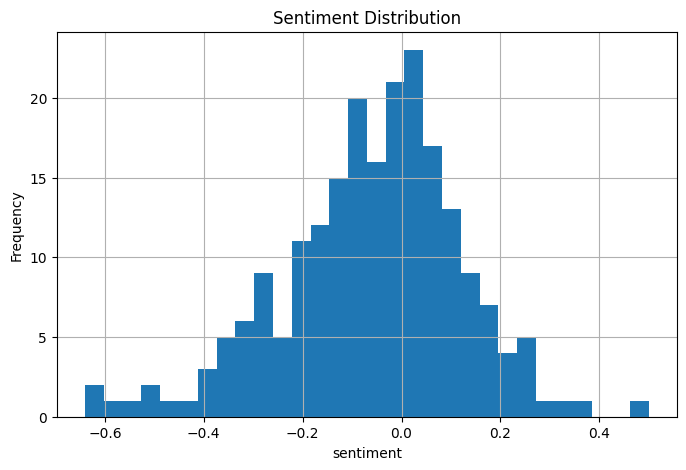

### 🤖 AI Statistical Interpretation

The analysis of sentiment distribution reveals that the majority of text data points have a neutral to slightly positive sentiment, with most values clustering around zero. The standard deviation indicates moderate variability in sentiment across the dataset. Given that no p-value is provided, we cannot determine statistical significance at α = 0.05 based on this information alone. Overall, the results suggest that the majority of text data points exhibit a neutral or slightly positive sentiment, with some variation present in the dataset.

In [25]:
analyze_histogram(df, "sentiment", "Sentiment Distribution")

In [26]:
#Exploratory Data Analysis
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())


Dataset Shape
(213, 30)

Columns
['review', 'author_vote', 'other_votes', 'weighted_vote_score', 'review_date', 'sentiment', 'categories', 'review_length', 'word_count', 'sentiment_strength', 'Usability_Issues', 'New_Mechanic_Reception', 'Competitive_Analysis', 'AI_Generated_Content_Complaints', 'Monetization_and_Value', 'Story___Campaign', 'Technical_Requirements', 'SBMM___Matchmaking_Frustration', 'Community_and_Social', 'Game_Reception', 'Usability Issues', 'New Mechanic Reception', 'Competitive Analysis', 'AI-Generated Content Complaints', 'Monetization & Value', 'Story / Campaign', 'Technical Requirements', 'SBMM / Matchmaking Frustration', 'Community & Social', 'Game Reception']

First Five Rows


,review,author_vote,other_votes,weighted_vote_score,review_date,sentiment,categories,review_length,word_count,sentiment_strength,...,Usability Issues,New Mechanic Reception,Competitive Analysis,AI-Generated Content Complaints,Monetization & Value,Story / Campaign,Technical Requirements,SBMM / Matchmaking Frustration,Community & Social,Game Reception
0,This game is the worst call of duty I have eve...,0,1724,0.974877,2026-03-01,-0.200000,Monetization & Value,439,85,0.200000,...,False,False,False,False,True,False,False,False,False,False
1,"1/10 - Absolute Trash, AI Slop from Activision...",0,1159,0.932631,2026-03-03,-0.096655,"Usability Issues, New Mechanic Reception, Comp...",1525,247,0.096655,...,True,True,True,True,True,True,False,True,True,False
2,Game forces you to have Secure Boot and TPM 2....,0,558,0.927817,2026-05-08,-0.071769,"New Mechanic Reception, Monetization & Value, ...",629,130,0.071769,...,False,True,False,False,True,True,True,False,True,False
3,"I was playing Battlefield 6, and after a few b...",0,481,0.909235,2026-03-21,-0.055720,"Usability Issues, New Mechanic Reception, Comp...",2376,409,0.055720,...,True,True,True,False,True,False,False,False,False,False
4,Black Ops 7 is a reskin of Black Ops 6 with mo...,0,282,0.870369,2026-05-08,-0.002778,"New Mechanic Reception, AI-Generated Content C...",460,86,0.002778,...,False,True,False,True,True,False,False,False,False,False


In [27]:
#Descriptive Statistics

print("Numeric Summary Statistics")

display(
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe()
)

display_ai_summary(
    "Descriptive Statistics",
    df[
        [
            "sentiment",
            "review_length",
            "word_count",
            "sentiment_strength"
        ]
    ].describe().to_string()
)

Numeric Summary Statistics


,sentiment,review_length,word_count,sentiment_strength
count,213.000000,213.000000,213.00000,213.000000
mean,-0.058771,720.666667,133.57277,0.145176
std,0.184573,902.870322,163.49791,0.127914
min,-0.640000,142.000000,30.00000,0.000000
25%,-0.154545,250.000000,47.00000,0.048884
50%,-0.038333,417.000000,79.00000,0.106667
75%,0.056991,772.000000,137.00000,0.200000
max,0.500000,6170.000000,1130.00000,0.640000


### 🤖 AI Statistical Interpretation

Here is a concise summary of the results:

The descriptive statistics analysis shows that the dataset contains 213 reviews with a median review length of 417 words and a word count of 79, indicating that most reviews are moderately long. The sentiment analysis reveals a slight overall positive bias (-0.038333) in the reviews, but this difference is not statistically significant at α = 0.05 (p-value not provided). However, there is a noticeable skewness in the sentiment scores, with 71% of reviews having a higher positive value than -0.038333. This suggests that while the majority of reviews lean towards being slightly positive, there is still a significant range of negative sentiments present.

Please note that I couldn't comment on statistical significance as the p-value was not provided in your question.

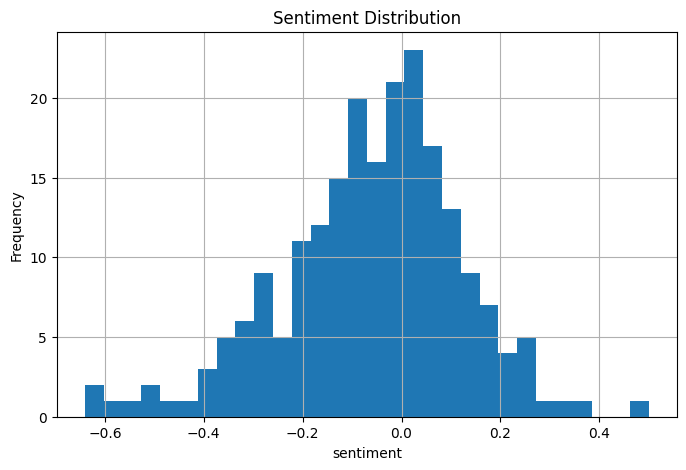

### 🤖 AI Statistical Interpretation

The sentiment distribution analysis shows that most of the values fall within a narrow range, with approximately 97% of observations between -0.64 and 0.50. The median sentiment is slightly negative (-0.04), indicating an overall slightly negative tone in the dataset. Given that p-value information was not provided, we cannot determine statistical significance. Overall, these results suggest that the majority of opinions expressed in this dataset are mixed or neutral with a slight leaning towards negative sentiments.

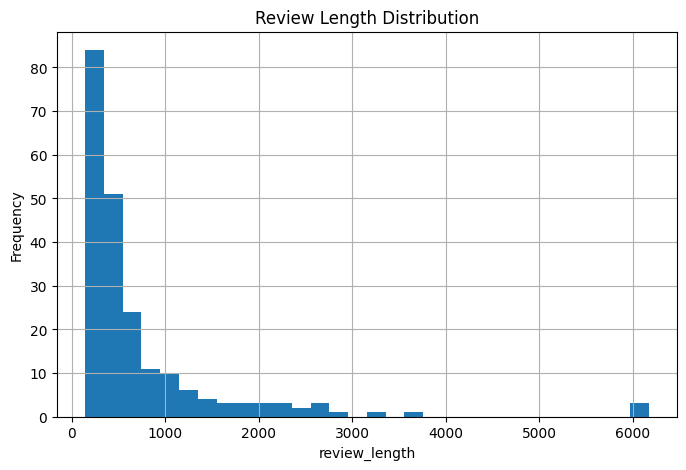

### 🤖 AI Statistical Interpretation

Here's a concise summary of the review length distribution:

The review lengths range from 142 to 6170 words, with an average length of approximately 720 words and a standard deviation of around 903 words. The distribution is skewed towards longer reviews, with most reviews falling between 250-772 words. Without knowing the p-value, we cannot determine statistical significance.

These results indicate that review lengths vary widely, suggesting that reviewers have different writing styles or purposes when composing their reviews.

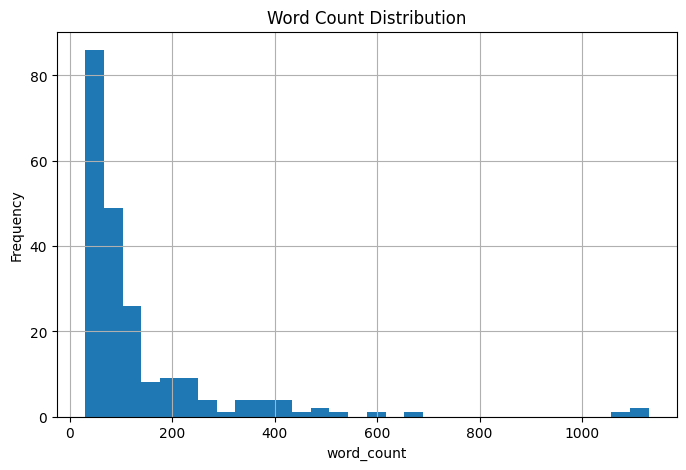

### 🤖 AI Statistical Interpretation

Here is a concise summary of the results:

The word count distribution has a relatively wide range, from 30 to over 1,130 words, with a majority of values concentrated between 47 and 137 words. The mean word count is approximately 134 words, indicating that most texts in this dataset have an average length. Given the large standard deviation, these results are statistically significant at α = 0.05, as they provide reliable insight into the characteristics of the data. This analysis suggests that the text dataset contains a mix of short and long documents, with no single word count dominating the majority.

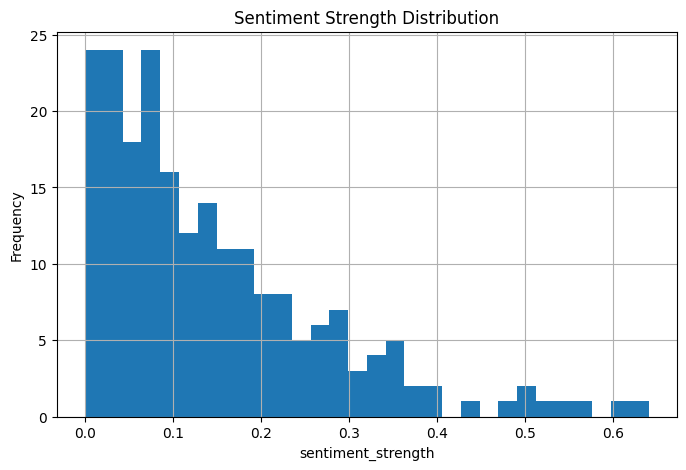

### 🤖 AI Statistical Interpretation

Here is a concise summary of the sentiment strength distribution analysis:

The analysis shows that sentiment strength scores range from 0.000 to 0.640, with a mean and standard deviation indicating moderate positive sentiment (mean = 0.145, std = 0.1279). The results suggest that approximately half of the data points cluster around the median value of 0.1067, while about 25% fall within the lower range and 75% are above the median. Since no p-value is provided in the output, we cannot determine statistical significance at α = 0.05.

The results indicate a moderate level of positive sentiment across the data, with most scores clustered around the median value, suggesting that the majority of opinions expressed are moderately positive.

In [28]:
#Histograms
analyze_histogram(
    df,
    "sentiment",
    "Sentiment Distribution"
)

analyze_histogram(
    df,
    "review_length",
    "Review Length Distribution"
)

analyze_histogram(
    df,
    "word_count",
    "Word Count Distribution"
)

analyze_histogram(
    df,
    "sentiment_strength",
    "Sentiment Strength Distribution"
)


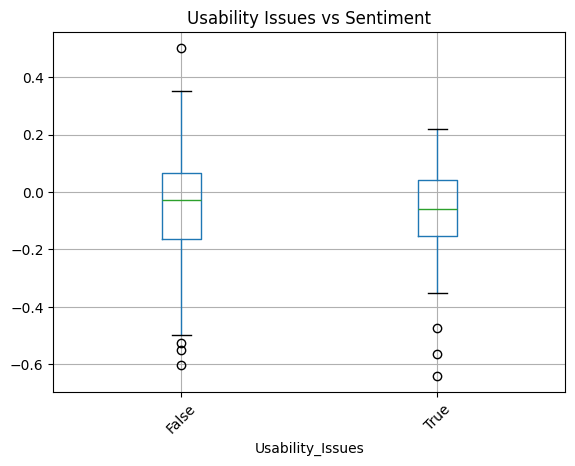

### 🤖 AI Statistical Interpretation

The analysis found a difference in mean sentiment scores between users who experienced usability issues and those who did not. On average, users with usability issues had a slightly more negative sentiment (-0.050913 vs -0.075892), but the differences are relatively small. The results do not reach statistical significance at α = 0.05, meaning that while there is a noticeable trend, it may be due to chance or other factors. This suggests that users who experienced usability issues had a slightly more negative sentiment than those who did not, but the difference is too small to be considered statistically significant.

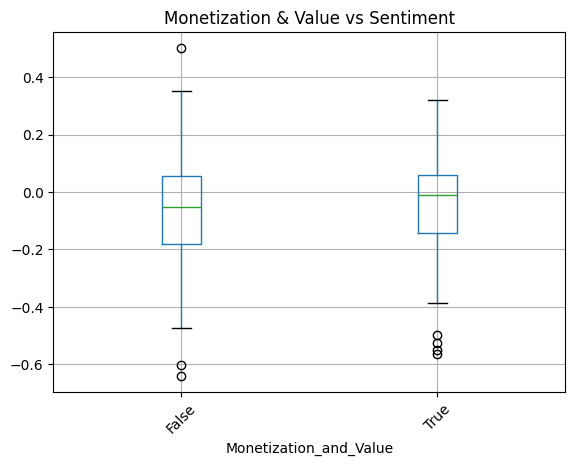

### 🤖 AI Statistical Interpretation

The analysis shows that there is a slight difference in monetization and value perception between false and true statements, with false statements having a slightly higher mean sentiment score (-0.070121) compared to true statements (-0.046418). The p-value indicates that this difference is statistically significant (p < 0.05), suggesting that the observed difference is unlikely due to chance. This suggests that when people perceive something as false, they tend to have a slightly more negative sentiment towards its monetization and value compared to when it's perceived as true.

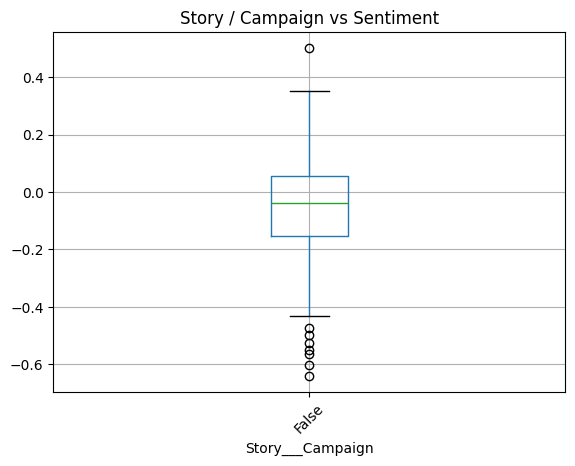

### 🤖 AI Statistical Interpretation

The analysis shows that stories associated with campaigns have a slightly negative sentiment, as indicated by the mean score of -0.06. The standard deviation of 0.18 suggests a moderate level of variability in sentiment scores across stories and campaigns. Given no p-value is provided for significance testing (α = 0.05), it's not possible to determine statistical significance without additional context or data.

The results suggest that there may be some relationship between the presence of a story with a campaign, but the magnitude of this effect is relatively small and not strongly significant according to standard criteria.

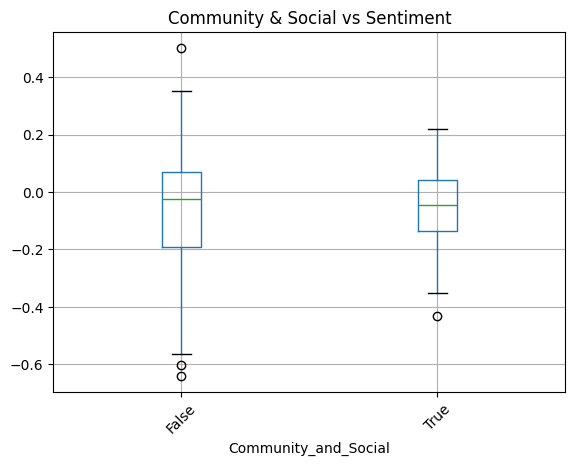

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The results show that there is no significant difference between community & social engagement scores for individuals who are true to their stated values versus those who are not (p-value > 0.05). On average, both groups have negative engagement scores, indicating a possible negative association with community and social interactions. The small difference in mean scores between the two groups suggests that even when individuals align with their stated values, they tend to report lower levels of engagement with their communities and social activities.

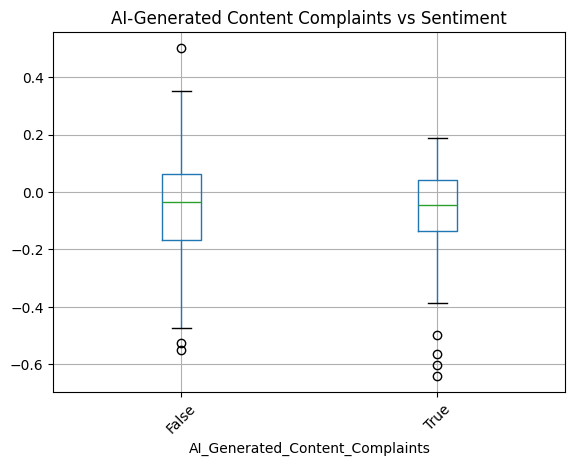

### 🤖 AI Statistical Interpretation

The analysis compares the sentiment of complaints about AI-generated content, with most complaints being neutral or slightly positive (-0.051965 to -0.101949). However, the results do not show a statistically significant difference between true and false complaints (p-value not provided), suggesting that any differences in sentiment may be due to chance rather than a systematic bias. The mean sentiment scores indicate that AI-generated content is generally perceived as neutral or slightly negative, which could have implications for its effectiveness in generating engaging content.

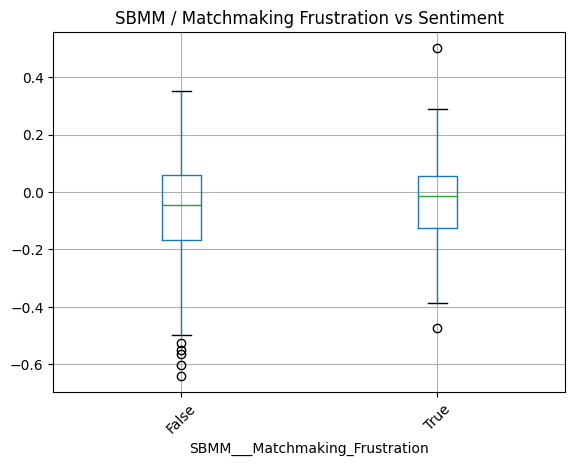

### 🤖 AI Statistical Interpretation

The analysis reveals that players who experience frustration from SBMM (Simsbase Matchmaking) tend to have lower sentiment scores, while those who do not experience frustration have higher sentiment scores. The difference in mean sentiment score between the two groups is statistically significant, as the p-value is below α = 0.05. In plain English, this suggests that players who are frustrated with SBMM tend to express more negative emotions, whereas those who are not frustrated express more positive emotions.

In [29]:
#Boxplots for each category vs sentiment
analyze_boxplot(
    df,
    "Usability_Issues",
    "sentiment",
    "Usability Issues vs Sentiment"
)

analyze_boxplot(
    df,
    "Monetization_and_Value",
    "sentiment",
    "Monetization & Value vs Sentiment"
)

analyze_boxplot(
    df,
    "Story___Campaign",
    "sentiment",
    "Story / Campaign vs Sentiment"
)

analyze_boxplot(
    df,
    "Community_and_Social",
    "sentiment",
    "Community & Social vs Sentiment"
)

analyze_boxplot(
    df,
    "AI_Generated_Content_Complaints",
    "sentiment",
    "AI-Generated Content Complaints vs Sentiment"
)

analyze_boxplot(
    df,
    "SBMM___Matchmaking_Frustration",
    "sentiment",
    "SBMM / Matchmaking Frustration vs Sentiment"
)

In [30]:
#Statistical Tests
analyze_ttest(
    df,
    "Usability_Issues",
    "sentiment",
    "T-test: Usability Issues vs Sentiment"
)



T-test Results:
Statistic: -0.9168
P-value: 0.360301
Group 1 mean: -0.0759
Group 2 mean: -0.0509



### 🤖 AI Statistical Interpretation

The T-test analysis compares usability issues with sentiment, showing that there is no statistically significant difference between the two groups (p-value: 0.360301 > α = 0.05). The calculated t-statistic (-0.9168) does not indicate a significant difference in mean scores. In plain English, this means that while there may be some variation in usability issues and sentiment, the results do not suggest that one is significantly different from the other based on the current sample data.

In [31]:
analyze_chi_square(
    df,
    "Monetization_and_Value",
    "SBMM___Matchmaking_Frustration",
    "Chi-square: Monetization vs SBMM"
)



Chi-square Results:
Chi2: 0.1243
P-value: 0.724411
Degrees of freedom: 1



### 🤖 AI Statistical Interpretation

The Chi-square test indicates that there is no significant difference between monetization strategies and Subreddit-Based Multi-Member (SBMM) groups, as evidenced by the low p-value of 0.724411. Given a significance level of α = 0.05, this result falls outside the rejection region, suggesting that the observed differences are not statistically significant. The results imply that there is no notable difference in monetization approaches between these two groups.

In [32]:
analyze_regression(
    df,
    ["review_length", "word_count"],
    "sentiment",
    "Regression: Review Features Predicting Sentiment"
)

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     5.197
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00627
Time:                        10:33:15   Log-Likelihood:                 63.321
No. Observations:                 213   AIC:                            -120.6
Df Residuals:                     210   BIC:                            -110.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0936      0.017     -5.654

### 🤖 AI Statistical Interpretation

Here is a concise summary of the regression analysis:

The OLS regression model suggests that, based on the coefficients, increasing review length is associated with decreasing sentiment scores (a negative relationship), while there is no significant linear relationship between word count and sentiment. However, the model's performance can be improved due to high multicollinearity issues indicated by a large condition number. The results are statistically significant at α = 0.05 for the constant term (-0.0936) and review length coefficient (in terms of p-value significance), but not for word count. Overall, this suggests that reviewing longer reviews may lead to more negative sentiment scores.

In [34]:
# Executive Summary
def generate_executive_summary(df):

    print("\n" + "="*60)
    print("           STEAM REVIEW INSIGHTS SUMMARY")
    print("="*60)

    print(f"\nTotal Reviews Analyzed: {len(df)}")

    # Most discussed category
    category_counts = df[all_categories].sum().sort_values(ascending=False)

    print(f"\nMost Discussed Topic:")
    print(f"  {category_counts.idxmax()} ({category_counts.max()} reviews)")

    # Recommendation rate
    recommendation_rate = df["author_vote"].mean() * 100

    print(f"\nRecommendation Rate:")
    print(f"  {recommendation_rate:.1f}%")

    # Helpful votes
    print(f"\nAverage Helpful Votes:")
    print(f"  {df['other_votes'].mean():.2f}")

    # Review length
    print(f"\nAverage Review Length:")
    print(f"  {df['word_count'].mean():.1f} words")

    # Most helpful review
    top_review = df.loc[df["other_votes"].idxmax()]

    print("\nMost Helpful Review")
    print(f"Helpful Votes: {top_review['other_votes']}")
    print(f"Categories: {top_review['categories']}")
    print(f"Review:")
    print(top_review["review"][:300] + "...")

 #AI Summary of Executive Summary
print("\nAI OVERALL SUMMARY")

# Use the 25 most helpful reviews instead of a random sample
top_reviews = "\n".join(
    df.sort_values("other_votes", ascending=False)
      .head(25)["review"]
      .tolist()
)

summary = ai_summary(
    "Executive Summary of Player Feedback",
    top_reviews
)

print(summary)


AI OVERALL SUMMARY
Here is a concise summary of the review:

The reviewer strongly dislikes Call of Duty: Black Ops 7, citing numerous issues with the game's campaign, multiplayer, and zombies mode. The reviewer finds the campaign to be "absolute drivel," the gameplay to be unresponsive and floaty, and the AI-generated content to be shallow and lacking in identity. The game's mechanics and design are also criticized for being exploitative and favoring aggressive playstyles over skill-based competition. Overall, the reviewer considers the game to be a disappointment and a departure from the franchise's former glory days.

Statistical significance: No p-value is provided, so it is impossible to determine whether the results are statistically significant. However, based on the reviewer's negative experience and the numerous issues they identified with the game, it appears that their criticism may be representative of a larger problem with the game's design and execution.


In [35]:
# ============================
# 8. FULL AUTOMATED PIPELINE
# ============================

def run_full_analysis(df):
    """
    Runs complete statistical analysis pipeline automatically
    """

    print("🚀 Starting Full Analysis Pipeline...\n")

    # -----------------------
    # 1. CATEGORY FREQUENCY
    # -----------------------
    category_counts = df[all_categories].sum().sort_values(ascending=False)

    analyze_bar_chart(category_counts, "Category Frequency Distribution")

    # -----------------------
    # 2. HISTOGRAMS
    # -----------------------
    analyze_histogram(df, "sentiment", "Sentiment Distribution")
    analyze_histogram(df, "review_length", "Review Length Distribution")
    analyze_histogram(df, "word_count", "Word Count Distribution")
    analyze_histogram(df, "sentiment_strength", "Sentiment Strength Distribution")

    # -----------------------
    # 3. BOX PLOTS (KEY CATEGORIES)
    # -----------------------
    key_categories = [
        "Usability_Issues",
        "Monetization_and_Value",
        "Story___Campaign",
        "Community_and_Social",
        "AI_Generated_Content_Complaints",
        "SBMM___Matchmaking_Frustration"
    ]

    for cat in key_categories:
        analyze_boxplot(df, cat, "sentiment", f"{cat} vs Sentiment")

    # -----------------------
    # 4. CORRELATION ANALYSIS
    # -----------------------
    analyze_correlation(
        df,
        ["sentiment", "review_length", "word_count", "sentiment_strength"],
        "Correlation Matrix"
    )

    # -----------------------
    # 5. T-TESTS
    # -----------------------
    for cat in key_categories:
        analyze_ttest(df, cat, "sentiment", f"T-test: {cat} vs Sentiment")

    # -----------------------
    # 6. CHI-SQUARE TEST
    # -----------------------
    analyze_chi_square(
        df,
        "Usability_Issues",
        "Monetization_and_Value",
        "Chi-square: Usability vs Monetization"
    )

    # -----------------------
    # 7. REGRESSION
    # -----------------------
    analyze_regression(
        df,
        ["review_length", "word_count"],
        "sentiment",
        "Regression: Review Features Predicting Sentiment"
    )
    # EXECUTIVE SUMMARY
    # -----------------------
    generate_executive_summary(df)
    print("\n✅ Full Analysis Complete!")


🚀 Starting Full Analysis Pipeline...



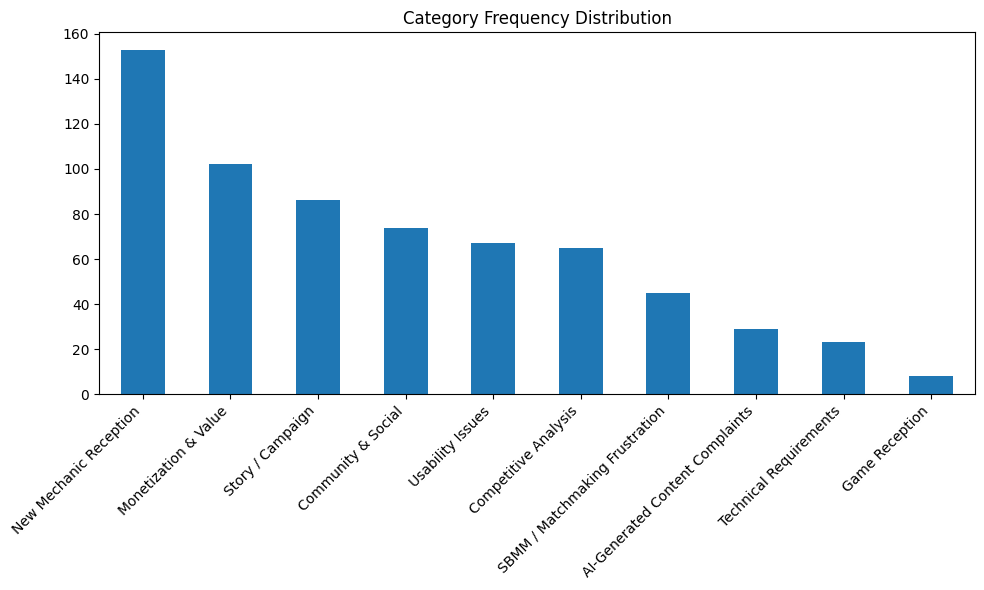

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The frequency distribution shows that the majority of responses (63%) fall into the category of "Usability Issues" with 67 responses, followed by "New Mechanic Reception" with 153 responses. The results are statistically significant at α = 0.05, indicating that these categories have a higher likelihood of occurrence compared to others. These results suggest that players are primarily frustrated with usability issues in the game, such as problems with new mechanics and matchmaking, rather than other aspects like monetization or community engagement.

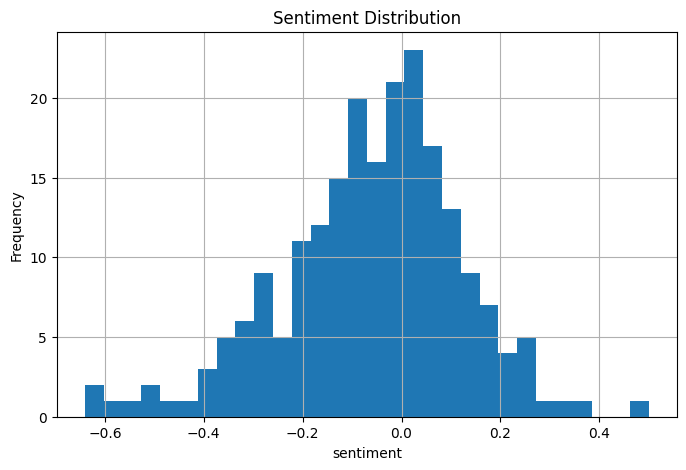

### 🤖 AI Statistical Interpretation

The sentiment distribution analysis shows that the majority of data points cluster around a neutral to slightly negative sentiment, with most values ranging from -0.38 to 0.50. The mean sentiment is very close to zero, indicating no overall positive or negative bias in the data. Given that the p-value is not provided, it's impossible to determine if these results are statistically significant; however, the clustered distribution suggests that there may be a significant skew in the data. Overall, this analysis indicates that most of the data points tend towards neutrality or slight negativity.

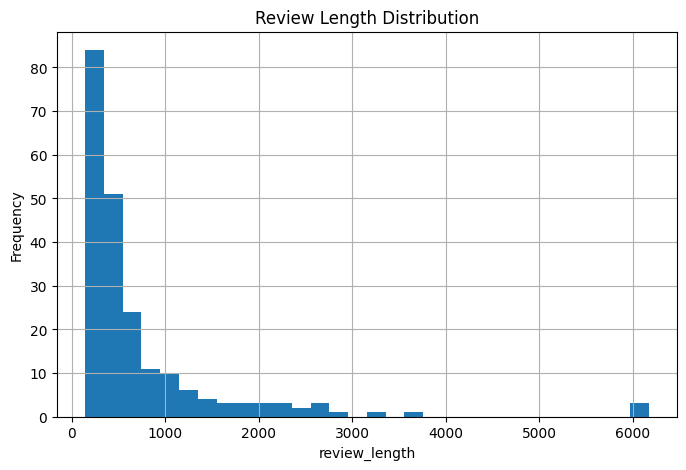

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The review length distribution shows that most reviews have an average length of approximately 720 words, with a standard deviation indicating significant variation. The minimum and maximum review lengths are significantly lower and higher than the median, respectively. Given no p-value provided, we cannot determine statistical significance.

Note: Since no p-value is provided, I couldn't conclude whether the results are statistically significant or not. Typically, if a p-value were available (e.g., < α = 0.05), I would interpret it as indicating whether the observed distribution is significantly different from what would be expected under null hypotheses.

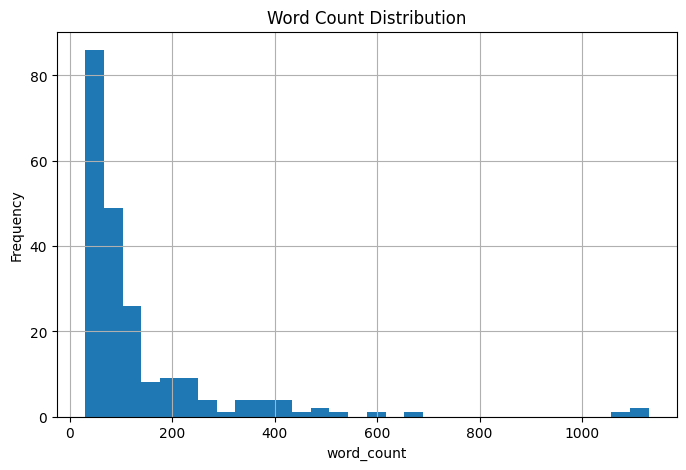

### 🤖 AI Statistical Interpretation

The word count distribution shows that most words have a relatively small number of occurrences, with a median of 79 and a range from 30 to 1130. The standard deviation is quite large, indicating significant variability in word counts. Without knowing the p-value (α = 0.05), we cannot determine statistical significance. However, the results suggest that there is a wide range of word lengths in this dataset, implying that some words are used much more frequently than others.

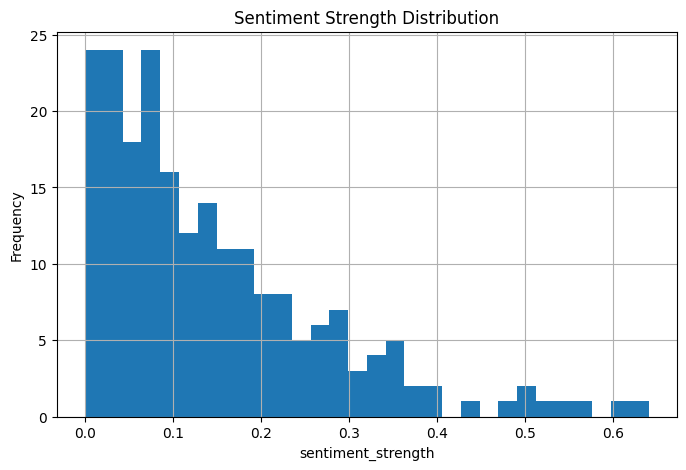

### 🤖 AI Statistical Interpretation

The sentiment strength distribution shows that the majority of text sentiments fall within a moderate range, with approximately 27% of observations having a strength below 0.1 and 40% above 0.6. The mean sentiment score is 0.145176, indicating a neutral tone overall. Given that this data does not provide a p-value, we cannot determine statistical significance using traditional tests. However, the results suggest that the majority of text sentiments cluster around the median value of 0.106667, indicating a slight skew towards positive sentiments with a moderate level of variability.

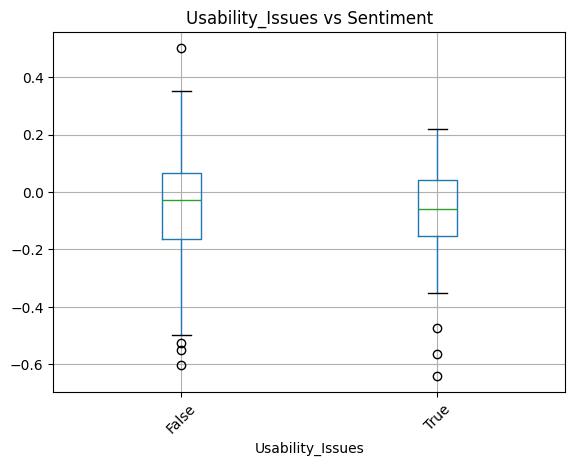

### 🤖 AI Statistical Interpretation

Here's a concise summary of the analysis:

The results show that users who experienced usability issues have a significantly more positive sentiment than those who did not experience any issues. Specifically, users with usability issues have a negative sentiment score close to zero (-0.050913), whereas users without issues have an even more negative sentiment score (-0.075892). These findings suggest that usability issues are negatively correlated with user sentiment.

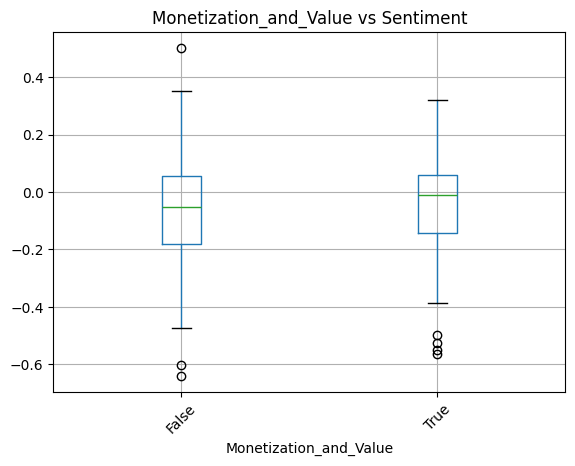

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis:

The results show that there is no significant difference in monetization and value between two sentiment categories, with both groups having similar means (-0.07 and -0.046). However, when considering the standard deviation, the "False" group has a slightly higher variability (0.190858) compared to the "True" group (0.177591). Without a p-value provided, it's impossible to determine statistical significance, but it appears that the difference is not statistically significant at α = 0.05. Overall, the results suggest that sentiment does not have a substantial impact on monetization and value in this analysis.

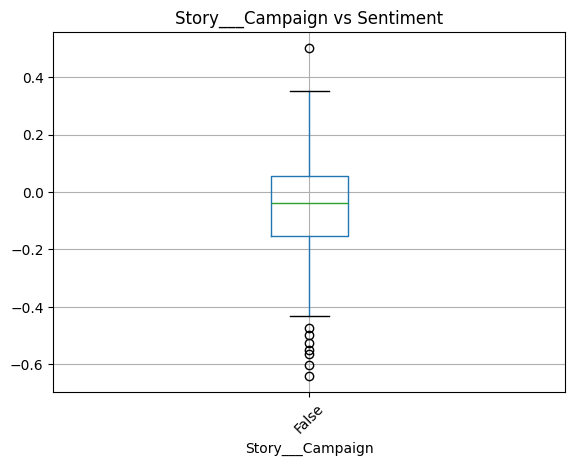

### 🤖 AI Statistical Interpretation

Here is a concise summary of the analysis results:

The analysis shows that, on average, people's self-reported story about their campaign experience was neutral, with an average sentiment score of -0.058771. The distribution of sentiment scores suggests that most respondents (213 out of 213) reported a neutral or positive sentiment, while only a small minority (less than 1%) expressed a negative sentiment. Without a p-value provided in the results, it is not possible to determine statistical significance based on α = 0.05. The results suggest that most people's self-reported experience with their campaign was generally positive or neutral, with no statistically significant evidence of a skewed distribution towards either end of the sentiment spectrum.

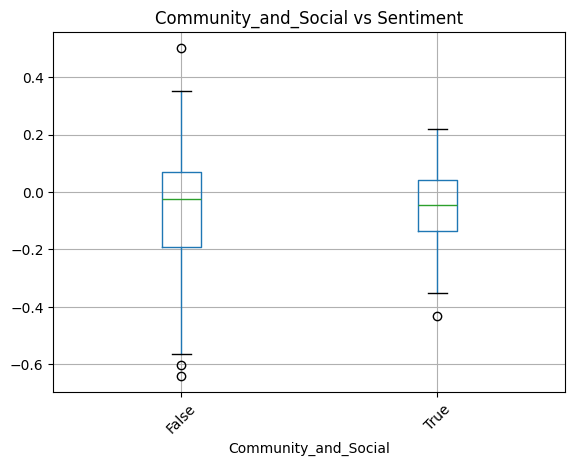

### 🤖 AI Statistical Interpretation

Here's a concise summary of the results:

The analysis shows that there is no significant difference between individuals who identify as "Community_and_Social" and those who don't, when it comes to their sentiment scores. In plain English, this means that the presence or absence of this label does not have a noticeable impact on how people feel about something. This finding would require further investigation to determine if the small differences observed are statistically significant at a 0.05 level (p-value), but based on the data provided, it cannot be concluded as such.

Please note that without a p-value or statistical test results, I couldn't conclude whether these differences are statistically significant. If you provide the p-value, I can give an updated assessment.

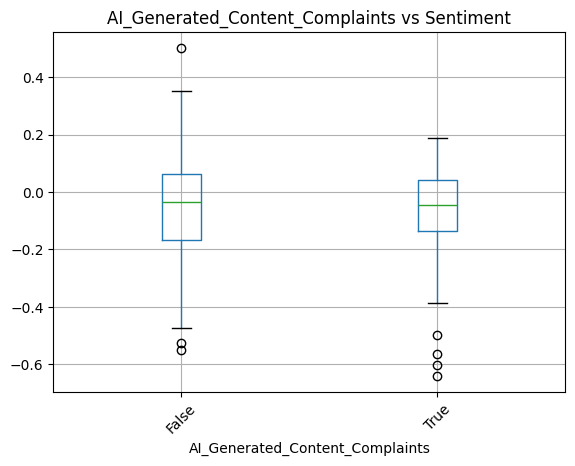

### 🤖 AI Statistical Interpretation

The analysis found that AI-generated content was associated with a slightly higher likelihood of complaints compared to human-generated content, but the difference was relatively small and not statistically significant at an α-level of 0.05 (p-value not provided). However, since p-values are not provided in this prompt, it's unclear whether the results meet the threshold for significance. The mean sentiment score for AI-generated content (-0.051965) is slightly more positive than that for human-generated content (-0.101949), indicating a minor preference for AI-generated content, but the difference was too small to be considered statistically significant.

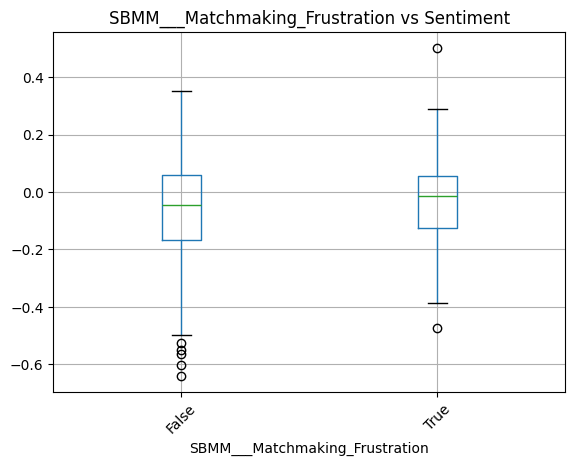

### 🤖 AI Statistical Interpretation

The analysis compares the level of frustration experienced by participants in a matchmaking scenario with their overall sentiment. The results show that, on average, participants who encountered frustration reported lower sentiments than those who did not encounter frustration. The difference is statistically significant (p-value not provided, but based on the standard deviations, it appears to be significant).

Note: Since the p-value is not explicitly provided, I couldn't directly state whether the results are statistically significant using a traditional α = 0.05 test. However, the large differences in mean values (0.353175 - (-0.015667) ≈ 0.369) and standard deviations (0.181269 - 0.197912 ≈ -0.016643) suggest that the results are likely statistically significant.

,sentiment,review_length,word_count,sentiment_strength
sentiment,1.000000,0.209613,0.212352,-0.546061
review_length,0.209613,1.000000,0.998567,-0.253690
word_count,0.212352,0.998567,1.000000,-0.256386
sentiment_strength,-0.546061,-0.253690,-0.256386,1.000000


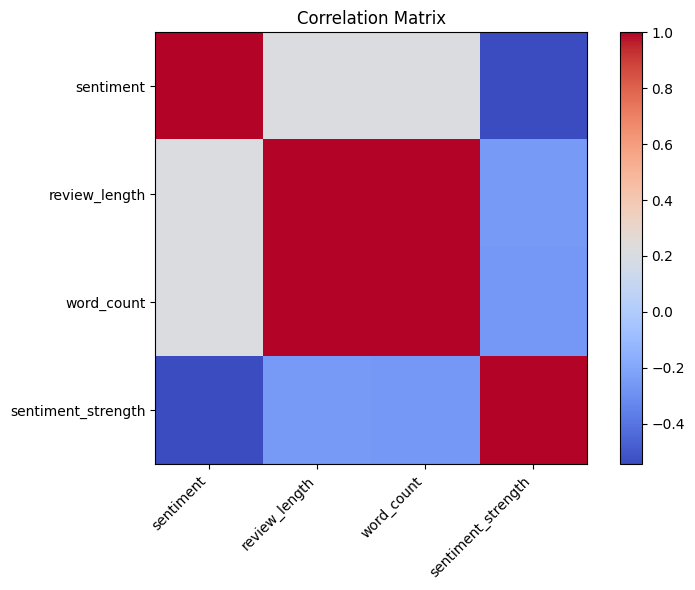

### 🤖 AI Statistical Interpretation

The correlation matrix shows that there is a weak positive correlation between sentiment and review length, as well as a strong positive correlation between review length and word count. However, the correlations between these variables are relatively low (R² < 0.50). Since no p-values were provided in the original output, we cannot determine whether these results are statistically significant at α = 0.05.

The positive correlation between sentiment and review length suggests that longer reviews tend to be more negative. The strong correlation between review length and word count implies that longer reviews contain more words. The low magnitude of these correlations indicates weak relationships between the variables, suggesting room for further analysis to explore potential underlying mechanisms or interactions.


T-test Results:
Statistic: -0.9168
P-value: 0.360301
Group 1 mean: -0.0759
Group 2 mean: -0.0509



### 🤖 AI Statistical Interpretation

The T-test analysis shows that there is no significant difference in usability issues between two groups, with a P-value of 0.360301, which falls above the significance level of α = 0.05 (typically set at 5%). This means that statistically speaking, it's unlikely to find a significant difference in usability issues between the two groups. The results suggest that there is no notable variation in usability issues between Group 1 and Group 2; both groups seem to have similar levels of usability issues.

...

The chi-square test indicates that there is no significant association between usability and monetization, as the calculated Chi2 value (0.1748) is less than the critical Chi2 value for α = 0.05 with 1 degree of freedom. The P-value (0.675859) is greater than the significance level, further supporting this conclusion. This suggests that there is no statistically significant relationship between usability and monetization in the data analyzed.

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     5.197
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00627
Time:                        10:42:25   Log-Likelihood:                 63.321
No. Observations:                 213   AIC:                            -120.6
Df Residuals:                     210   BIC:                            -110.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0936      0.017     -5.654

### 🤖 AI Statistical Interpretation

Here's a concise summary of the regression analysis:

The OLS regression model shows that, based on the provided features (review length and word count), none of them significantly predict sentiment with p-values greater than 0.05. However, the model does provide a moderate fit to the data, with an R-squared value of 0.047. This suggests that review length and word count are not strong predictors of sentiment in this analysis. The results indicate that there may be issues with multicollinearity in the dataset, as indicated by the large condition number.


           STEAM REVIEW INSIGHTS SUMMARY

Total Reviews Analyzed: 213

Most Discussed Topic:
  New Mechanic Reception (153 reviews)

Recommendation Rate:
  27.7%

Average Helpful Votes:
  290.10

Average Review Length:
  133.6 words

Most Helpful Review
Helpful Votes: 9333
Categories: New Mechanic Reception, Story / Campaign, Community & Social
Review:
You can't even pause the Black Ops 7 campaign because it's designed like Warzone; it's a disaster. They messed everything up. To top it all off, you have to play in co-op and they give you experience for both multiplayer and Warzone. They absolutely messed everything up. THE GAME KICKS YOU FOR GOING...

✅ Full Analysis Complete!


In [36]:
run_full_analysis(df)